In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mnist import load_mnist
from multi_layer_net import MultiLayerNetExtend

In [2]:

(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True)

In [3]:
x_train = x_train[:1000]
t_train = t_train[:1000]

max_epochs = 20
train_size = x_train.shape[0]
batch_size = 100
learning_rate = 0.01

In [4]:
class SGD:
    def __init__(self, lr=0.01):
        self.lr = lr
        
    def update(self, params, grads):
        for key in params.keys():
            params[key] -= self.lr * grads[key] 

In [5]:
def __train(weight_init_std):
    bn_network = MultiLayerNetExtend(input_size=784, hidden_size_list=[100, 100, 100, 100, 100], output_size=10, 
                                    weight_init_std=weight_init_std, use_batchnorm=True)
    network = MultiLayerNetExtend(input_size=784, hidden_size_list=[100, 100, 100, 100, 100], output_size=10,
                                weight_init_std=weight_init_std)
    optimizer = SGD(lr=learning_rate)
    
    train_acc_list = []
    bn_train_acc_list = []
    
    iter_per_epoch = max(train_size / batch_size, 1)
    epoch_cnt = 0
    
    for i in range(1000000000):
        batch_mask = np.random.choice(train_size, batch_size)
        x_batch = x_train[batch_mask]
        t_batch = t_train[batch_mask]
    
        for _network in (bn_network, network):
            grads = _network.gradient(x_batch, t_batch)
            optimizer.update(_network.params, grads)
    
        if i % iter_per_epoch == 0:
            train_acc = network.accuracy(x_train, t_train)
            bn_train_acc = bn_network.accuracy(x_train, t_train)
            train_acc_list.append(train_acc)
            bn_train_acc_list.append(bn_train_acc)
    
            print("epoch:" + str(epoch_cnt) + " | " + str(train_acc) + " - " + str(bn_train_acc))
    
            epoch_cnt += 1
            if epoch_cnt >= max_epochs:
                break
                
    return train_acc_list, bn_train_acc_list


epoch:0 | 0.102 - 0.104
epoch:1 | 0.108 - 0.143
epoch:2 | 0.111 - 0.305
epoch:3 | 0.117 - 0.481
epoch:4 | 0.121 - 0.558
epoch:5 | 0.129 - 0.636
epoch:6 | 0.145 - 0.678
epoch:7 | 0.154 - 0.712
epoch:8 | 0.162 - 0.738
epoch:9 | 0.173 - 0.77
epoch:10 | 0.178 - 0.785
epoch:11 | 0.197 - 0.803
epoch:12 | 0.204 - 0.817
epoch:13 | 0.21 - 0.828
epoch:14 | 0.218 - 0.845
epoch:15 | 0.216 - 0.85
epoch:16 | 0.22 - 0.862
epoch:17 | 0.234 - 0.877
epoch:18 | 0.237 - 0.884
epoch:19 | 0.244 - 0.895


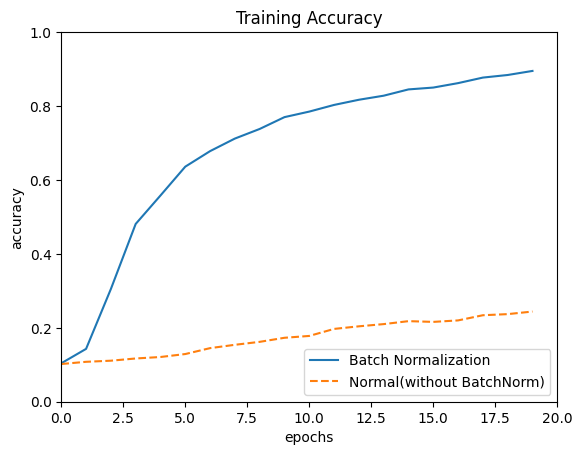

In [6]:
weight_scale_list = np.logspace(0, -4, num=16)
x = np.arange(max_epochs)

train_acc_list, bn_train_acc_list = __train(weight_scale_list[4])
    
plt.title("Training Accuracy")
plt.plot(x, bn_train_acc_list, label='Batch Normalization', markevery=2)
plt.plot(x, train_acc_list, linestyle = "--", label='Normal(without BatchNorm)', markevery=2)
plt.ylim(0, 1.0)
plt.xlim(0, max_epochs)
plt.ylabel("accuracy")
plt.xlabel("epochs")
plt.legend(loc='lower right')
    
plt.show()

In [7]:
def __train(weight_init_std):
    bn_network = MultiLayerNetExtend(input_size=784, hidden_size_list=[100, 100, 100, 100, 100], output_size=10, 
                                    weight_init_std=weight_init_std, use_batchnorm=True)
    network = MultiLayerNetExtend(input_size=784, hidden_size_list=[100, 100, 100, 100, 100], output_size=10,
                                weight_init_std=weight_init_std)
    optimizer = SGD(lr=learning_rate)
    
    train_acc_list = []
    bn_train_acc_list = []
    
    iter_per_epoch = max(train_size / batch_size, 1)
    epoch_cnt = 0
    
    for i in range(1000000000):
        batch_mask = np.random.choice(train_size, batch_size)
        x_batch = x_train[batch_mask]
        t_batch = t_train[batch_mask]
    
        for _network in (bn_network, network):
            grads = _network.gradient(x_batch, t_batch)
            optimizer.update(_network.params, grads)
    
        if i % iter_per_epoch == 0:
            train_acc = network.accuracy(x_train, t_train)
            bn_train_acc = bn_network.accuracy(x_train, t_train)
            train_acc_list.append(train_acc)
            bn_train_acc_list.append(bn_train_acc)
    
            print("epoch:" + str(epoch_cnt) + " | " + str(train_acc) + " - " + str(bn_train_acc))
    
            epoch_cnt += 1
            if epoch_cnt >= max_epochs:
                break
                
    return train_acc_list, bn_train_acc_list

============== 1/16 ==============
epoch:0 | 0.117 - 0.029
epoch:1 | 0.097 - 0.052
epoch:2 | 0.097 - 0.094
epoch:3 | 0.097 - 0.106
epoch:4 | 0.097 - 0.126
epoch:5 | 0.097 - 0.145
epoch:6 | 0.097 - 0.17


/Users/wonkikim/study/deeplearning/deep_learning_from_scratch/vol1/chapter6/src/multi_layer_net.py:179: RuntimeWarning: overflow encountered in square
  weight_decay += 0.5 * self.weight_decay_lambda * np.sum(W**2)
/Users/wonkikim/study/deeplearning/deep_learning_from_scratch/vol1/chapter6/src/multi_layer_net.py:179: RuntimeWarning: invalid value encountered in scalar multiply
  weight_decay += 0.5 * self.weight_decay_lambda * np.sum(W**2)


epoch:7 | 0.097 - 0.203
epoch:8 | 0.097 - 0.222
epoch:9 | 0.097 - 0.239
epoch:10 | 0.097 - 0.255
epoch:11 | 0.097 - 0.28
epoch:12 | 0.097 - 0.295
epoch:13 | 0.097 - 0.309
epoch:14 | 0.097 - 0.335
epoch:15 | 0.097 - 0.344
epoch:16 | 0.097 - 0.352
epoch:17 | 0.097 - 0.38
epoch:18 | 0.097 - 0.388
epoch:19 | 0.097 - 0.39
============== 2/16 ==============
epoch:0 | 0.105 - 0.102
epoch:1 | 0.097 - 0.119
epoch:2 | 0.097 - 0.158


/Users/wonkikim/study/deeplearning/deep_learning_from_scratch/vol1/chapter6/src/layers.py:39: RuntimeWarning: invalid value encountered in subtract
  x = x - np.max(x, axis=1, keepdims=True)


epoch:3 | 0.097 - 0.184
epoch:4 | 0.097 - 0.207
epoch:5 | 0.097 - 0.219
epoch:6 | 0.097 - 0.24
epoch:7 | 0.097 - 0.26
epoch:8 | 0.097 - 0.28
epoch:9 | 0.097 - 0.293
epoch:10 | 0.097 - 0.308
epoch:11 | 0.097 - 0.327
epoch:12 | 0.097 - 0.349
epoch:13 | 0.097 - 0.37
epoch:14 | 0.097 - 0.392
epoch:15 | 0.097 - 0.41
epoch:16 | 0.097 - 0.435
epoch:17 | 0.097 - 0.446
epoch:18 | 0.097 - 0.465
epoch:19 | 0.097 - 0.474
============== 3/16 ==============
epoch:0 | 0.133 - 0.097
epoch:1 | 0.403 - 0.127
epoch:2 | 0.52 - 0.166
epoch:3 | 0.62 - 0.225
epoch:4 | 0.686 - 0.256
epoch:5 | 0.737 - 0.288
epoch:6 | 0.762 - 0.33
epoch:7 | 0.795 - 0.356
epoch:8 | 0.844 - 0.391
epoch:9 | 0.866 - 0.419
epoch:10 | 0.874 - 0.447
epoch:11 | 0.901 - 0.465
epoch:12 | 0.933 - 0.491
epoch:13 | 0.941 - 0.523
epoch:14 | 0.941 - 0.544
epoch:15 | 0.952 - 0.566
epoch:16 | 0.962 - 0.581
epoch:17 | 0.963 - 0.6
epoch:18 | 0.975 - 0.626
epoch:19 | 0.977 - 0.641
============== 4/16 ==============
epoch:0 | 0.103 - 0.066
epoch:1 

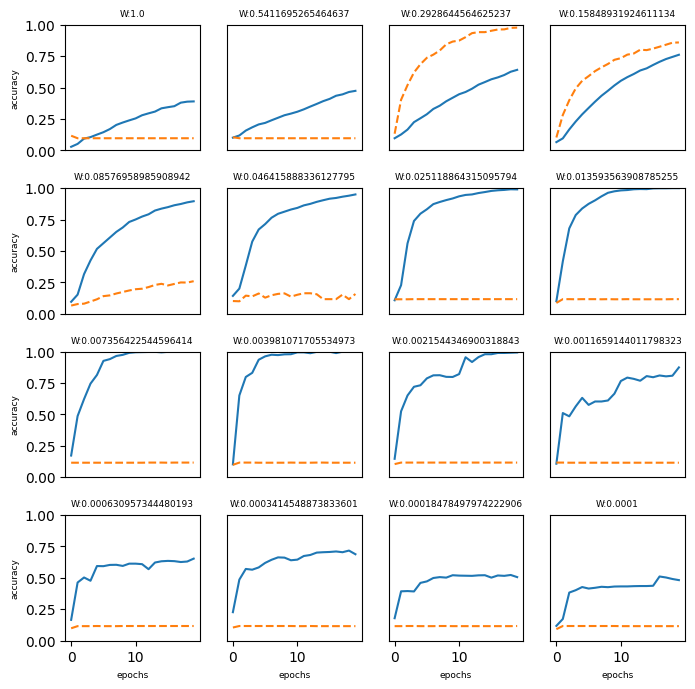

In [8]:
weight_scale_list = np.logspace(0, -4, num=16)
x = np.arange(max_epochs)

plt.figure(figsize=(8, 8))

for i, w in enumerate(weight_scale_list):
    print( "============== " + str(i+1) + "/16" + " ==============")
    train_acc_list, bn_train_acc_list = __train(w)
    
    plt.subplot(4,4,i+1)
    plt.title("W:" + str(w), fontsize=6.5)
    plt.plot(x, bn_train_acc_list, markevery=2)
    plt.plot(x, train_acc_list, linestyle="--", markevery=2)

    plt.ylim(0, 1.0)
    if i % 4:
        plt.yticks([])
    else:
        plt.ylabel("accuracy", fontsize=6.5)
    if i < 12:
        plt.xticks([])
    else:
        plt.xlabel("epochs", fontsize=6.5)
    
plt.subplots_adjust(wspace=0.2, hspace=0.3)    
plt.show()